<a href="https://colab.research.google.com/github/edgi-govdata-archiving/GHG-CDP/blob/main/EJSCREEN_Climate_Data_Merge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EJ Screen Climate Change Indicators

This notebook merges together data from EJScreen (v2.32 2024). Specifically, it combines climate change indicators data with core environmental indicators, indices, and demographic indices. We calculate national percentiles based on EJScreen extreme heat data, and then we identify block groups in the top twenty percent (≥80th percentile) nationally for flood, wildfire, and extreme heat, and air pollution indicators, *and* either of the two social vulnerability indices (the demographic index or the supplemental demographic index). For greater consistency across data sources, we focused on data from the contiguous US.

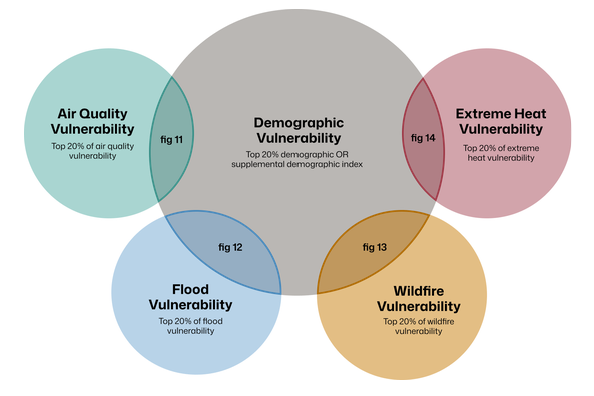

#1. Import Dependencies
Import the required libraries and mount your google drive (use one with permissions for the EDGI shared drive)

In [1]:
import pandas as pd
import geopandas as gpd

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#2. Load EJ Screen

In [2]:
# Load EJScreen data, drop geometry for now
ejscreen = gpd.read_file("/content/drive/Shareddrives/EDGI - Shared NEW/12_Environmental_Enforcement_Watch/09_Data/EJScreen_2024_BG_with_AS_CNMI_GU_VI.gdb").drop(columns="geometry")

/usr/local/lib/python3.12/dist-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'EJScreen_2024_BG_with_AS_CNMI_GU_VI.gdb': 'EJSCREEN_Full_with_AS_CNMI_GU_VI' (default), 'USA'. Specify layer parameter to avoid this warning.
  result = read_func(


In [ ]:
#Optional cell to see the column names within the EJScreen file
# ejscreen_columns = ejscreen.columns.tolist()
# ejscreen_columns

['ID',
 'STATE_NAME',
 'ST_ABBREV',
 'CNTY_NAME',
 'REGION',
 'ACSTOTPOP',
 'ACSIPOVBAS',
 'ACSEDUCBAS',
 'ACSTOTHH',
 'ACSTOTHU',
 'ACSUNEMPBAS',
 'ACSDISABBAS',
 'DEMOGIDX_2',
 'DEMOGIDX_5',
 'PEOPCOLOR',
 'PEOPCOLORPCT',
 'LOWINCOME',
 'LOWINCPCT',
 'UNEMPLOYED',
 'UNEMPPCT',
 'DISABILITY',
 'DISABILITYPCT',
 'LINGISO',
 'LINGISOPCT',
 'LESSHS',
 'LESSHSPCT',
 'UNDER5',
 'UNDER5PCT',
 'OVER64',
 'OVER64PCT',
 'LIFEEXPPCT',
 'PM25',
 'OZONE',
 'DSLPM',
 'RSEI_AIR',
 'PTRAF',
 'PRE1960',
 'PRE1960PCT',
 'PNPL',
 'PRMP',
 'PTSDF',
 'UST',
 'PWDIS',
 'NO2',
 'DWATER',
 'D2_PM25',
 'D5_PM25',
 'D2_OZONE',
 'D5_OZONE',
 'D2_DSLPM',
 'D5_DSLPM',
 'D2_RSEI_AIR',
 'D5_RSEI_AIR',
 'D2_PTRAF',
 'D5_PTRAF',
 'D2_LDPNT',
 'D5_LDPNT',
 'D2_PNPL',
 'D5_PNPL',
 'D2_PRMP',
 'D5_PRMP',
 'D2_PTSDF',
 'D5_PTSDF',
 'D2_UST',
 'D5_UST',
 'D2_PWDIS',
 'D5_PWDIS',
 'D2_NO2',
 'D5_NO2',
 'D2_DWATER',
 'D5_DWATER',
 'P_DEMOGIDX_2',
 'P_DEMOGIDX_5',
 'P_PEOPCOLORPCT',
 'P_LOWINCPCT',
 'P_UNEMPPCT',
 'P_DISABI

#3. Load EJ Screen Climate Change Indicators

Load data for EJ Screen Climate Change indicators from EDGI's Google Drive. These are not yet part of the EJ Screen file above, so we'll need to prepare them and then merge them.

In [3]:
flood_risk = gpd.read_file("/content/drive/Shareddrives/EDGI - Shared NEW/12_Environmental_Enforcement_Watch/09_Data/EPA_EJScreen_Flood_Risk.gdb")
heat_risk = gpd.read_file("/content/drive/Shareddrives/EDGI - Shared NEW/12_Environmental_Enforcement_Watch/09_Data/Heat_Index.gdb")
wildfire_risk = gpd.read_file("/content/drive/Shareddrives/EDGI - Shared NEW/12_Environmental_Enforcement_Watch/09_Data/Wildfire_Risk.gdb")


In [4]:
ejscreen["ID"] = ejscreen["ID"].astype(str).str.zfill(12)
wildfire_risk["ID"] = wildfire_risk["ID"].astype(str).str.zfill(12)
flood_risk["ID"] = flood_risk["ID"].astype(str).str.zfill(12)
heat_risk["ID"] = heat_risk["ID"].astype(str).str.zfill(12)


In [5]:
state_abbrev_to_name = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico",
    "NY": "New York", "NC": "North Carolina", "ND": "North Dakota",
    "OH": "Ohio", "OK": "Oklahoma", "OR": "Oregon", "PA": "Pennsylvania",
    "RI": "Rhode Island", "SC": "South Carolina", "SD": "South Dakota",
    "TN": "Tennessee", "TX": "Texas", "UT": "Utah", "VT": "Vermont",
    "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming",
    "DC": "District of Columbia", "PR": "Puerto Rico"
}


In [6]:
flood_risk["STATE_NAME"] = flood_risk["ST_ABBREV"].map(
    state_abbrev_to_name
)
wildfire_risk["STATE_NAME"] = wildfire_risk["ST_ABBREV"].map(
    state_abbrev_to_name
)

In [7]:
contiguous_states = [
    "Alabama", "Arizona", "Arkansas", "California", "Colorado", "Connecticut",
    "Delaware", "Florida", "Georgia", "Idaho", "Illinois", "Indiana", "Iowa",
    "Kansas", "Kentucky", "Louisiana", "Maine", "Maryland", "Massachusetts",
    "Michigan", "Minnesota", "Mississippi", "Missouri", "Montana", "Nebraska",
    "Nevada", "New Hampshire", "New Jersey", "New Mexico", "New York",
    "North Carolina", "North Dakota", "Ohio", "Oklahoma", "Oregon",
    "Pennsylvania", "Rhode Island", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "Vermont", "Virginia", "Washington",
    "West Virginia", "Wisconsin", "Wyoming"
]


In [8]:
flood_risk = flood_risk[flood_risk["STATE_NAME"].isin(contiguous_states)]
heat_risk = heat_risk[heat_risk["STATE_NAME"].isin(contiguous_states)]
wildfire_risk = wildfire_risk[wildfire_risk["STATE_NAME"].isin(contiguous_states)]


#4. Calculate Extreme Heat Risk percentiles for consistency

We'll calculate national percentiles for extreme heat based on the maximum number of days above 90 degress F for each census block group.

In [9]:
#Note: "average" is the defualt when calculating %iles this way, so tied values get the mean of their ranks, so two values tied at the 50th percentile both get "50"
heat_risk["PERCENTILES"] = (
    heat_risk["Max_Days_Above_90"]
    .rank(pct=True)
    * 100
)


In [10]:
heat_risk["PERCENTILES"] = heat_risk["PERCENTILES"].round(2)


In [11]:
heat_risk[["Max_Days_Above_90","PERCENTILES"]].describe()

,Max_Days_Above_90,PERCENTILES
count,237622.000000,237622.000000
mean,53.666041,50.000027
std,45.670607,28.864636
min,0.000000,1.520000
25%,16.000000,24.550000
50%,37.000000,50.070000
75%,87.000000,74.900000
max,222.000000,100.000000


#5. Then merge them with EJ Screen based on their census block group IDs
And make sure to rename "PERCENTILE" columns from the different data sources so it's less confusing after the join.

In [12]:
ejscreen = ejscreen.rename(columns={
        "P_PM25": "pm25_pct",
        "P_NO2": "no2_pct",
        "P_OZONE": "ozone_pct",
        "P_RSEI_AIR": "rsei_pct",
        "P_DSLPM": "dieselpm_pct",
        "P_PTRAF": "traffic_pct"
    })
#We could merge simultaneously, but let's just merge two df at a time to keep an eye on the results
#     .merge(
#         wildfire_risk[["ID", "PERCENTILE", "T_fire_y30"]].rename(columns={"PERCENTILE": "wildfire_pct"}),
#         on="ID", how="left"
#     )
#     .merge(
#         flood_risk[["ID", "PERCENTILE", "T_flood_y30"]].rename(columns={"PERCENTILE": "flood_pct"}),
#         on="ID", how="left"
#     )
#     .merge(
#         heat_risk[["ID", "PERCENTILES"]].rename(columns={"PERCENTILES": "heat_pct"}),
#         on="ID", how="left"
#     )
# )

In [14]:
ej_cc_wildfire = ejscreen.merge(
        wildfire_risk[["ID", "PERCENTILE", "T_fire_y30"]].rename(columns={"PERCENTILE": "wildfire_pct"}),
        on="ID", how="left"
    )
ej_cc_wildfire

,ID,STATE_NAME,ST_ABBREV,CNTY_NAME,REGION,ACSTOTPOP,ACSIPOVBAS,ACSEDUCBAS,ACSTOTHH,ACSTOTHU,...,NPL_CNT,TSDF_CNT,EXCEED_COUNT_80,EXCEED_COUNT_80_SUP,DEMOGIDX_2ST,DEMOGIDX_5ST,Shape_Length,Shape_Area,wildfire_pct,T_fire_y30
0,010010201001,Alabama,AL,Autauga County,4,558.0,558.0,423.0,261.0,279.0,...,0.0,0.0,1.0,4.0,1.362959,2.249444,0.110793,0.000412,81.0,81 %ile
1,010010201002,Alabama,AL,Autauga County,4,1307.0,1307.0,843.0,439.0,454.0,...,0.0,0.0,1.0,2.0,0.796153,1.929149,0.096868,0.000534,0.0,84 %ile
2,010010202001,Alabama,AL,Autauga County,4,548.0,540.0,428.0,204.0,276.0,...,0.0,0.0,3.0,2.0,1.840541,1.687681,0.062129,0.000197,0.0,80 %ile
3,010010202002,Alabama,AL,Autauga County,4,1313.0,1129.0,1047.0,340.0,404.0,...,0.0,0.0,1.0,2.0,1.529810,1.675390,0.052097,0.000122,0.0,72 %ile
4,010010203001,Alabama,AL,Autauga County,4,2835.0,2829.0,1863.0,1011.0,1115.0,...,0.0,0.0,1.0,1.0,0.958818,1.511979,0.089441,0.000372,79.0,79 %ile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243017,007801035150,Virgin Islands,VI,St. Croix Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.053795,0.000125,NaN,NaN
243018,007801007850,Virgin Islands,VI,St. Croix Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.065407,0.000157,NaN,NaN
243019,007803054875,Virgin Islands,VI,St. Thomas Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.092625,0.000252,NaN,NaN
243020,007802008700,Virgin Islands,VI,St. John Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.050068,0.000096,NaN,NaN


In [15]:
ej_cc_wf_flood = ej_cc_wildfire.merge(
        flood_risk[["ID", "PERCENTILE", "T_flood_y30"]].rename(columns={"PERCENTILE": "flood_pct"}),
        on="ID", how="left"
    )
ej_cc_wf_flood

,ID,STATE_NAME,ST_ABBREV,CNTY_NAME,REGION,ACSTOTPOP,ACSIPOVBAS,ACSEDUCBAS,ACSTOTHH,ACSTOTHU,...,EXCEED_COUNT_80,EXCEED_COUNT_80_SUP,DEMOGIDX_2ST,DEMOGIDX_5ST,Shape_Length,Shape_Area,wildfire_pct,T_fire_y30,flood_pct,T_flood_y30
0,010010201001,Alabama,AL,Autauga County,4,558.0,558.0,423.0,261.0,279.0,...,1.0,4.0,1.362959,2.249444,0.110793,0.000412,81.0,81 %ile,95.0,94 %ile
1,010010201002,Alabama,AL,Autauga County,4,1307.0,1307.0,843.0,439.0,454.0,...,1.0,2.0,0.796153,1.929149,0.096868,0.000534,0.0,84 %ile,45.0,42 %ile
2,010010202001,Alabama,AL,Autauga County,4,548.0,540.0,428.0,204.0,276.0,...,3.0,2.0,1.840541,1.687681,0.062129,0.000197,0.0,80 %ile,40.0,40 %ile
3,010010202002,Alabama,AL,Autauga County,4,1313.0,1129.0,1047.0,340.0,404.0,...,1.0,2.0,1.529810,1.675390,0.052097,0.000122,0.0,72 %ile,94.0,93 %ile
4,010010203001,Alabama,AL,Autauga County,4,2835.0,2829.0,1863.0,1011.0,1115.0,...,1.0,1.0,0.958818,1.511979,0.089441,0.000372,79.0,79 %ile,42.0,42 %ile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243017,007801035150,Virgin Islands,VI,St. Croix Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.053795,0.000125,NaN,NaN,NaN,NaN
243018,007801007850,Virgin Islands,VI,St. Croix Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.065407,0.000157,NaN,NaN,NaN,NaN
243019,007803054875,Virgin Islands,VI,St. Thomas Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.092625,0.000252,NaN,NaN,NaN,NaN
243020,007802008700,Virgin Islands,VI,St. John Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.050068,0.000096,NaN,NaN,NaN,NaN


In [17]:
ej_cc = ej_cc_wf_flood.merge(
        heat_risk[["ID", "PERCENTILES"]].rename(columns={"PERCENTILES": "heat_pct"}),
        on="ID", how="left"
    )
ej_cc

,ID,STATE_NAME,ST_ABBREV,CNTY_NAME,REGION,ACSTOTPOP,ACSIPOVBAS,ACSEDUCBAS,ACSTOTHH,ACSTOTHU,...,EXCEED_COUNT_80_SUP,DEMOGIDX_2ST,DEMOGIDX_5ST,Shape_Length,Shape_Area,wildfire_pct,T_fire_y30,flood_pct,T_flood_y30,heat_pct
0,010010201001,Alabama,AL,Autauga County,4,558.0,558.0,423.0,261.0,279.0,...,4.0,1.362959,2.249444,0.110793,0.000412,81.0,81 %ile,95.0,94 %ile,80.0
1,010010201002,Alabama,AL,Autauga County,4,1307.0,1307.0,843.0,439.0,454.0,...,2.0,0.796153,1.929149,0.096868,0.000534,0.0,84 %ile,45.0,42 %ile,80.0
2,010010202001,Alabama,AL,Autauga County,4,548.0,540.0,428.0,204.0,276.0,...,2.0,1.840541,1.687681,0.062129,0.000197,0.0,80 %ile,40.0,40 %ile,80.0
3,010010202002,Alabama,AL,Autauga County,4,1313.0,1129.0,1047.0,340.0,404.0,...,2.0,1.529810,1.675390,0.052097,0.000122,0.0,72 %ile,94.0,93 %ile,80.0
4,010010203001,Alabama,AL,Autauga County,4,2835.0,2829.0,1863.0,1011.0,1115.0,...,1.0,0.958818,1.511979,0.089441,0.000372,79.0,79 %ile,42.0,42 %ile,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243017,007801035150,Virgin Islands,VI,St. Croix Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.053795,0.000125,NaN,NaN,NaN,NaN,NaN
243018,007801007850,Virgin Islands,VI,St. Croix Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.065407,0.000157,NaN,NaN,NaN,NaN,NaN
243019,007803054875,Virgin Islands,VI,St. Thomas Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.092625,0.000252,NaN,NaN,NaN,NaN,NaN
243020,007802008700,Virgin Islands,VI,St. John Island,2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.050068,0.000096,NaN,NaN,NaN,NaN,NaN


In [18]:
#Keep only valid results, drop NA
ej_cc = ej_cc.loc[
    (ej_cc["pm25_pct"].notna()) &
    (ej_cc["dieselpm_pct"].notna()) &
    (ej_cc["rsei_pct"].notna()) &
    (ej_cc["ozone_pct"].notna()) &
    (ej_cc["no2_pct"].notna()) &
    (ej_cc["traffic_pct"].notna()) &
    (ej_cc["wildfire_pct"].notna()) &
    (ej_cc["heat_pct"].notna()) &
    (ej_cc["flood_pct"].notna())
].copy()


Thresholds (80th %ile)

Here we will use a threshold to identify block groups that are greater than or equal to the 80th %ile for flood (2030), wildfire (2030), and extreme heat. Later, we'll calculate the % of block groups within a congressional district that meet these criteria.

In [ ]:
#Convert %iles from string to number for 2030 model

In [19]:
ej_cc["flood_pct_2030"] = (
    ej_cc["T_flood_y30"]
    .str.replace("%ile", "", regex=False)
    .astype(int)
)
ej_cc["wildfire_pct_2030"] = (
    ej_cc["T_fire_y30"]
    .str.replace("%ile", "", regex=False)
    .astype(int)
)

In [20]:
#Air Quality + demographic threshold
ej_cc["airquality_demog_high"] = (
    (ej_cc["pm25_pct"] >= 80)|
    (ej_cc["dieselpm_pct"] >= 80)|
    (ej_cc["rsei_pct"] >= 80)|
    (ej_cc["ozone_pct"] >= 80)|
    (ej_cc["no2_pct"] >= 80)|
    (ej_cc["traffic_pct"] >= 80) &
    (
    (ej_cc["P_DEMOGIDX_2"] >= 80)|
    (ej_cc["P_DEMOGIDX_5"] >= 80)
    )
).astype(int)

# Extreme heat risk + demographic threshold
ej_cc["heat_demog_high"] = (
    (ej_cc["heat_pct"] >= 80) &
    (
    (ej_cc["P_DEMOGIDX_2"] >= 80)|
    (ej_cc["P_DEMOGIDX_5"] >= 80)
    )
).astype(int)

# Flood risk + demographic threshold for 2020 data
ej_cc["flood_demog_high"] = (
    (ej_cc["flood_pct"] >= 80) &
    (
        (ej_cc["P_DEMOGIDX_2"] >= 80) |
        (ej_cc["P_DEMOGIDX_5"] >= 80)
    )
).astype(int)

# Wildfire risk + demographic threshold for 2020 data
ej_cc["wildfire_demog_high"] = (
    (ej_cc["wildfire_pct"] >= 80) &
    (
    (ej_cc["P_DEMOGIDX_2"] >= 80)|
    (ej_cc["P_DEMOGIDX_5"] >= 80)
    )
).astype(int)


In [21]:
# Flood risk for 2030 model
ej_cc["flood_demog_high_2030"] = (
    (ej_cc["flood_pct_2030"] >= 80) &
    (
        (ej_cc["P_DEMOGIDX_2"] >= 80) |
        (ej_cc["P_DEMOGIDX_5"] >= 80)
    )
).astype(int)


# Wildfire risk for 2030 model
ej_cc["wildfire_demog_high_2030"] = (
    (ej_cc["wildfire_pct_2030"] >= 80) &
    (
    (ej_cc["P_DEMOGIDX_2"] >= 80)|
    (ej_cc["P_DEMOGIDX_5"] >= 80)
    )
).astype(int)


In [ ]:
#Optional cell to see the columns in the newly created df
# ej_cc_columns = ej_cc.columns.tolist()
# ej_cc_columns

['ID',
 'STATE_NAME',
 'ST_ABBREV',
 'CNTY_NAME',
 'REGION',
 'ACSTOTPOP',
 'ACSIPOVBAS',
 'ACSEDUCBAS',
 'ACSTOTHH',
 'ACSTOTHU',
 'ACSUNEMPBAS',
 'ACSDISABBAS',
 'DEMOGIDX_2',
 'DEMOGIDX_5',
 'PEOPCOLOR',
 'PEOPCOLORPCT',
 'LOWINCOME',
 'LOWINCPCT',
 'UNEMPLOYED',
 'UNEMPPCT',
 'DISABILITY',
 'DISABILITYPCT',
 'LINGISO',
 'LINGISOPCT',
 'LESSHS',
 'LESSHSPCT',
 'UNDER5',
 'UNDER5PCT',
 'OVER64',
 'OVER64PCT',
 'LIFEEXPPCT',
 'PM25',
 'OZONE',
 'DSLPM',
 'RSEI_AIR',
 'PTRAF',
 'PRE1960',
 'PRE1960PCT',
 'PNPL',
 'PRMP',
 'PTSDF',
 'UST',
 'PWDIS',
 'NO2',
 'DWATER',
 'D2_PM25',
 'D5_PM25',
 'D2_OZONE',
 'D5_OZONE',
 'D2_DSLPM',
 'D5_DSLPM',
 'D2_RSEI_AIR',
 'D5_RSEI_AIR',
 'D2_PTRAF',
 'D5_PTRAF',
 'D2_LDPNT',
 'D5_LDPNT',
 'D2_PNPL',
 'D5_PNPL',
 'D2_PRMP',
 'D5_PRMP',
 'D2_PTSDF',
 'D5_PTSDF',
 'D2_UST',
 'D5_UST',
 'D2_PWDIS',
 'D5_PWDIS',
 'D2_NO2',
 'D5_NO2',
 'D2_DWATER',
 'D5_DWATER',
 'P_DEMOGIDX_2',
 'P_DEMOGIDX_5',
 'P_PEOPCOLORPCT',
 'P_LOWINCPCT',
 'P_UNEMPPCT',
 'P_DISABI

In [ ]:
#Save outputs as .csv
ej_cc.to_csv("ej_cc_threshold_contiguous_us.csv", index = False)

In [ ]:
#Save outputs as .parquet
ej_cc.to_parquet("ej_cc_threshold_contiguous_us.parquet")